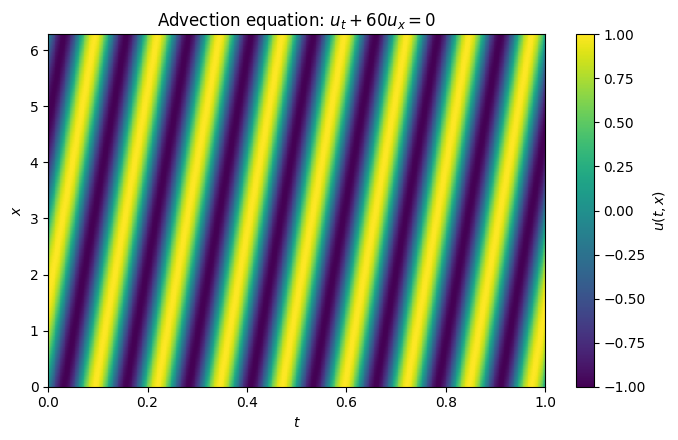

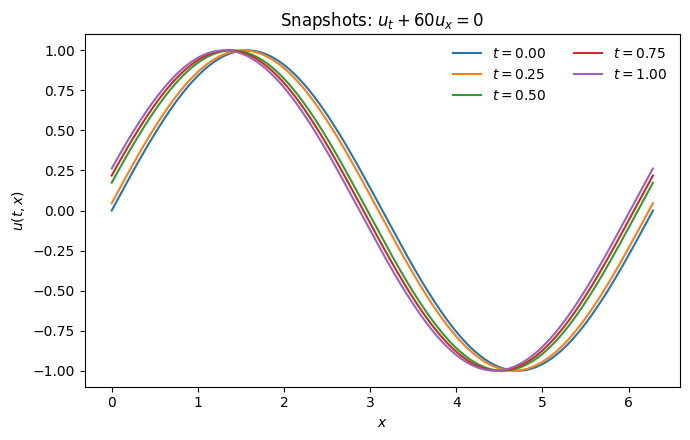

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Problem:
# u_t + c u_x = 0,  (t, x) in [0, T] x [0, L]
# u(0, x) = sin(x)
# periodic boundary: u(t, 0) = u(t, L)
#
# Exact solution:
# u(t, x) = sin((x - c t) mod L)

T = 1.0
L = 2 * np.pi
c = 40

n_t = 600
n_x = 256

# Grid
t_star = np.linspace(0.0, T, n_t)
x_star = np.linspace(0.0, L, n_x)

TT, XX = np.meshgrid(t_star, x_star, indexing="ij")

# Exact solution
X_shift = (XX - c * TT) % L
u_ref = np.sin(X_shift)

# Save data
np.savez(
    "advection_c60_data.npz",
    u_ref=u_ref,
    t_star=t_star,
    x_star=x_star,
    c=c,
    T=T,
    L=L,
)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    u_ref.T,
    origin="lower",
    aspect="auto",
    extent=[t_star[0], t_star[-1], x_star[0], x_star[-1]],
    interpolation="nearest",
)
cb = fig.colorbar(im, ax=ax)
cb.set_label(r"$u(t,x)$")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_title(r"Advection equation: $u_t + 60u_x = 0$")

fig.tight_layout()
plt.savefig("advection_c60_heatmap.png", dpi=300)
plt.show()

# Optional: solution snapshots
snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, ax = plt.subplots(figsize=(7, 4.5))
for ts in snapshot_times:
    idx = np.argmin(np.abs(t_star - ts))
    ax.plot(x_star, u_ref[idx], label=rf"$t={t_star[idx]:.2f}$")

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u(t,x)$")
ax.set_title(r"Snapshots: $u_t + 60u_x = 0$")
ax.legend(frameon=False, ncol=2)

fig.tight_layout()
plt.savefig("advection_c60_snapshots.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# Sto-SQP-PINN for 1D Transport / Advection Equation (JAX)
#
# This version follows the working transport setup:
#   - PDE:       u_t + c u_x = 0
#   - IC:        u(x,0) = sin(x)
#   - periodic:  u(0,t) = u(2*pi,t)
#   - derivative periodic BC is deleted
#   - fixed damping lambda = 1e-4
#   - scaled residual: (u_t + c u_x) / sqrt(1 + c^2)
#   - fixed base points + fresh Gaussian jitter each iteration
#
# Constraint vector:
#   c(theta) = [PDE residual anchors, periodic value BC, IC mismatch]
#
# Objective:
#   mean squared scaled PDE residual on a larger fixed/jittered set
# ============================================================

import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "2")
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import math
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

import jax.numpy as jnp
from jax import random, grad, vmap

DTYPE = jnp.float64
EPS = DTYPE(1e-12)

# ============================================================
# Problem setup
# ============================================================
T_FINAL = 1.0
L_DOMAIN = 2.0 * np.pi
C_ADV = 40.0

# Reference/evaluation grid.
# Use 200 x 128 for training diagnostics. Use a denser grid only for final figures if desired.
N_T_REF = 600
N_X_REF = 256

# Pure PINN/SQP by default. Set >0 only if you want supervised data anchors.
B_DATA = 0

# ============================================================
# Constraint counts
# ============================================================
NX_PDE_CON = 30
NT_PDE_CON = 30
K_PDE = NX_PDE_CON * NT_PDE_CON
N_PDE_PER_CELL = 1

K_BC = 100
N_BC_PER_BIN = 1

K_IC = 200
N_IC_PER_BIN = 1

# No derivative BC.
M_CON = K_PDE + K_BC + K_IC

# PDE objective points
NX_PDE_OBJ = 80
NT_PDE_OBJ = 80
K_PDE_OBJ = NX_PDE_OBJ * NT_PDE_OBJ


# ============================================================
# Dataset
# ============================================================
def generate_transport_dataset(T=T_FINAL, L=L_DOMAIN, c=C_ADV, n_t=N_T_REF, n_x=N_X_REF):
    t = np.linspace(0.0, T, n_t)
    x = np.linspace(0.0, L, n_x)
    TT, XX = np.meshgrid(t, x, indexing="ij")
    usol = np.sin((XX - c * TT) % L)
    return t, x, usol, float(c)


def build_full_data_points(t_np, x_np, usol_np):
    TT, XX = np.meshgrid(t_np, x_np, indexing="ij")
    X_data = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    u_data = usol_np.reshape(-1)
    return X_data, u_data


# ============================================================
# MLP
# ============================================================
def init_mlp_params(key, layer_sizes):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)
    for k, (m, n) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        W = random.normal(k, (m, n), dtype=DTYPE) * jnp.sqrt(DTYPE(2.0) / DTYPE(m))
        b = jnp.zeros((n,), dtype=DTYPE)
        params.append({"W": W, "b": b})
    return params


def normalize_xt(X):
    # X[:,0] = x in [0, L_DOMAIN], X[:,1] = t in [0, T_FINAL]
    x = X[:, 0:1]
    t = X[:, 1:2]
    x_n = DTYPE(2.0) * x / DTYPE(L_DOMAIN) - DTYPE(1.0)
    t_n = DTYPE(2.0) * t / DTYPE(T_FINAL) - DTYPE(1.0)
    return jnp.concatenate([x_n, t_n], axis=1)


def mlp_apply(params, X):
    h = normalize_xt(X)
    for i, layer in enumerate(params):
        W, b = layer["W"], layer["b"]
        h = h @ W + b
        if i < len(params) - 1:
            h = jnp.tanh(h)
    return h


def flatten_params(params):
    flat_parts = []
    shapes = []
    for layer in params:
        W, b = layer["W"], layer["b"]
        flat_parts.append(W.reshape(-1))
        flat_parts.append(b.reshape(-1))
        shapes.append((W.shape, b.shape))
    theta = jnp.concatenate(flat_parts).astype(DTYPE)
    return theta, tuple(shapes)


def unflatten_params(theta, shapes):
    params = []
    idx = 0
    for W_shape, b_shape in shapes:
        W_size = math.prod(W_shape)
        b_size = math.prod(b_shape)
        W = theta[idx: idx + W_size].reshape(W_shape)
        idx += W_size
        b = theta[idx: idx + b_size].reshape(b_shape)
        idx += b_size
        params.append({"W": W, "b": b})
    return params


# ============================================================
# Sampling utilities
# ============================================================
def segment_sum(values, segment_ids, num_segments):
    out = jnp.zeros((num_segments,), dtype=values.dtype)
    return out.at[segment_ids].add(values)


def sample_data_batch(key, X_data, u_data, B):
    if B == 0:
        return jnp.zeros((0, 2), dtype=DTYPE), jnp.zeros((0,), dtype=DTYPE)
    N = X_data.shape[0]
    idx = random.randint(key, (B,), 0, N)
    return X_data[idx], u_data[idx]


def sample_pde_obj_base_stratified(key, x_min, x_max, t_min, t_max):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_OBJ)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_OBJ)

    it, ix = jnp.meshgrid(jnp.arange(NT_PDE_OBJ), jnp.arange(NX_PDE_OBJ), indexing="ij")
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE_OBJ, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0 + u[:, 0] * dx
    ts = t0 + u[:, 1] * dt
    return jnp.stack([xs, ts], axis=1)


def sample_pde_stratified(key, x_min, x_max, t_min, t_max):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_CON)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_CON)

    it, ix = jnp.meshgrid(jnp.arange(NT_PDE_CON), jnp.arange(NX_PDE_CON), indexing="ij")
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)
    ids_cell = (it * NX_PDE_CON + ix).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE, N_PDE_PER_CELL, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0[:, None] + u[:, :, 0] * dx
    ts = t0[:, None] + u[:, :, 1] * dt

    X_f = jnp.stack([xs, ts], axis=-1).reshape(-1, 2)
    ids = jnp.repeat(ids_cell, N_PDE_PER_CELL)
    return X_f, ids


def sample_bc_stratified(key, x_min, x_max, t_min, t_max):
    # Periodic boundary pairs with matched times.
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(K_BC)
    j = jnp.arange(K_BC, dtype=jnp.int32)
    t0 = DTYPE(t_min) + DTYPE(j) * dt

    u = random.uniform(key, (K_BC, N_BC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    ts = (t0[:, None] + u * dt).reshape(-1, 1)
    ids = jnp.repeat(j, N_BC_PER_BIN)

    XL = jnp.concatenate([DTYPE(x_min) * jnp.ones_like(ts), ts], axis=1)
    XR = jnp.concatenate([DTYPE(x_max) * jnp.ones_like(ts), ts], axis=1)
    return XL, XR, ids


def sample_ic_stratified(key, x_min, x_max, t0):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(K_IC)
    j = jnp.arange(K_IC, dtype=jnp.int32)
    x0 = DTYPE(x_min) + DTYPE(j) * dx

    u = random.uniform(key, (K_IC, N_IC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = (x0[:, None] + u * dx).reshape(-1, 1)
    ids = jnp.repeat(j, N_IC_PER_BIN)

    Xic = jnp.concatenate([xs, DTYPE(t0) * jnp.ones_like(xs)], axis=1)
    u0 = jnp.sin(xs[:, 0])
    return Xic, u0, ids


# ============================================================
# Jitter utilities
# ============================================================
def jitter_points(key, X, x_min, x_max, t_min, t_max,
                  sigma_x, sigma_t, kind="gaussian", clip_k=2.0):
    if X.shape[0] == 0 or ((sigma_x <= 0.0) and (sigma_t <= 0.0)):
        return X

    key, kx, kt = random.split(key, 3)

    if kind == "gaussian":
        dx = DTYPE(sigma_x) * random.normal(kx, (X.shape[0],), dtype=DTYPE)
        dt = DTYPE(sigma_t) * random.normal(kt, (X.shape[0],), dtype=DTYPE)
        if clip_k is not None:
            k = DTYPE(clip_k)
            dx = jnp.clip(dx, -k * DTYPE(sigma_x), k * DTYPE(sigma_x))
            dt = jnp.clip(dt, -k * DTYPE(sigma_t), k * DTYPE(sigma_t))
    elif kind == "uniform":
        dx = DTYPE(sigma_x) * (DTYPE(2.0) * random.uniform(kx, (X.shape[0],), dtype=DTYPE) - DTYPE(1.0))
        dt = DTYPE(sigma_t) * (DTYPE(2.0) * random.uniform(kt, (X.shape[0],), dtype=DTYPE) - DTYPE(1.0))
    else:
        raise ValueError("kind must be 'gaussian' or 'uniform'")

    x = jnp.clip(X[:, 0] + dx, DTYPE(x_min), DTYPE(x_max))
    t = jnp.clip(X[:, 1] + dt, DTYPE(t_min), DTYPE(t_max))
    return jnp.stack([x, t], axis=1)


def jitter_bc_pair_time(key, XL, XR, x_min, x_max, t_min, t_max,
                        sigma_t, kind="gaussian", clip_k=2.0):
    # Same time noise for left/right paired boundary points.
    if XL.shape[0] == 0 or sigma_t <= 0.0:
        return XL, XR

    if kind == "gaussian":
        dt = DTYPE(sigma_t) * random.normal(key, (XL.shape[0],), dtype=DTYPE)
        if clip_k is not None:
            k = DTYPE(clip_k)
            dt = jnp.clip(dt, -k * DTYPE(sigma_t), k * DTYPE(sigma_t))
    elif kind == "uniform":
        dt = DTYPE(sigma_t) * (DTYPE(2.0) * random.uniform(key, (XL.shape[0],), dtype=DTYPE) - DTYPE(1.0))
    else:
        raise ValueError("kind must be 'gaussian' or 'uniform'")

    tL = jnp.clip(XL[:, 1] + dt, DTYPE(t_min), DTYPE(t_max))
    tR = jnp.clip(XR[:, 1] + dt, DTYPE(t_min), DTYPE(t_max))
    XL_use = jnp.stack([DTYPE(x_min) * jnp.ones_like(tL), tL], axis=1)
    XR_use = jnp.stack([DTYPE(x_max) * jnp.ones_like(tR), tR], axis=1)
    return XL_use, XR_use


def jitter_ic_x(key, Xic, x_min, x_max, t_min, sigma_x, kind="gaussian", clip_k=2.0):
    if Xic.shape[0] == 0 or sigma_x <= 0.0:
        return Xic, jnp.sin(Xic[:, 0])

    if kind == "gaussian":
        dx = DTYPE(sigma_x) * random.normal(key, (Xic.shape[0],), dtype=DTYPE)
        if clip_k is not None:
            k = DTYPE(clip_k)
            dx = jnp.clip(dx, -k * DTYPE(sigma_x), k * DTYPE(sigma_x))
    elif kind == "uniform":
        dx = DTYPE(sigma_x) * (DTYPE(2.0) * random.uniform(key, (Xic.shape[0],), dtype=DTYPE) - DTYPE(1.0))
    else:
        raise ValueError("kind must be 'gaussian' or 'uniform'")

    x = jnp.clip(Xic[:, 0] + dx, DTYPE(x_min), DTYPE(x_max))
    t = DTYPE(t_min) * jnp.ones_like(x)
    Xic_use = jnp.stack([x, t], axis=1)
    u0ic_use = jnp.sin(x)
    return Xic_use, u0ic_use


# ============================================================
# PDE residual
# ============================================================
def pde_residual(params, X_f, c):
    """
    Scaled transport residual:
        (u_t + c u_x) / sqrt(1+c^2)

    Scaling does not change the equality constraint but improves conditioning.
    """
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]

    du = vmap(grad(u_fun))(X_f)
    u_x = du[:, 0]
    u_t = du[:, 1]
    return (u_t + DTYPE(c) * u_x) / jnp.sqrt(DTYPE(1.0) + DTYPE(c) ** 2)


def pde_mse_on_points(theta, shapes, X_pts, c):
    params = unflatten_params(theta, shapes)
    r = pde_residual(params, X_pts, c)
    return jnp.mean(r ** 2)


# ============================================================
# Objective functions
# ============================================================
def data_mse_unscaled(params, Xb, ub):
    if Xb.shape[0] == 0:
        return DTYPE(0.0)
    pred = mlp_apply(params, Xb)[:, 0]
    return jnp.mean((pred - ub) ** 2)


@partial(jax.jit, static_argnames=("shapes",))
def F_and_g_data_scaled_batch(theta, shapes, Xb, ub, scale_obj):
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        return data_mse_unscaled(params, Xb, ub)

    val, g = jax.value_and_grad(obj_theta)(theta)
    return DTYPE(scale_obj) * val, DTYPE(scale_obj) * g


@partial(jax.jit, static_argnames=("shapes",))
def F_and_g_pde_obj(theta, shapes, X_obj, c, w_pde):
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        r = pde_residual(params, X_obj, c)
        return DTYPE(w_pde) * jnp.mean(r ** 2)

    val, g = jax.value_and_grad(obj_theta)(theta)
    return val, g


# ============================================================
# Constraints
# ============================================================
@partial(jax.jit, static_argnames=("shapes",))
def constraint_vector(theta, shapes,
                      X_f, ids_f,
                      X_bc_L, X_bc_R, ids_bc,
                      X_ic, u0_ic, ids_ic,
                      c):
    params = unflatten_params(theta, shapes)

    # PDE signed scaled residual.
    r = pde_residual(params, X_f, c)
    c_pde = segment_sum(r, ids_f, K_PDE) / DTYPE(N_PDE_PER_CELL)

    # Periodic value BC only.
    uL = mlp_apply(params, X_bc_L)[:, 0]
    uR = mlp_apply(params, X_bc_R)[:, 0]
    c_bc = segment_sum(uL - uR, ids_bc, K_BC) / DTYPE(N_BC_PER_BIN)

    # IC.
    u_ic = mlp_apply(params, X_ic)[:, 0]
    c_ic = segment_sum(u_ic - u0_ic, ids_ic, K_IC) / DTYPE(N_IC_PER_BIN)

    return jnp.concatenate([c_pde, c_bc, c_ic], axis=0)


@partial(jax.jit, static_argnames=("shapes",))
def C_and_J(theta, shapes,
            X_f, ids_f,
            X_bc_L, X_bc_R, ids_bc,
            X_ic, u0_ic, ids_ic,
            c):
    def c_fun(th):
        return constraint_vector(th, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, c)

    def c_fun_aux(th):
        cc = c_fun(th)
        return cc, cc

    J, cc = jax.jacrev(c_fun_aux, has_aux=True)(theta)
    return cc, J


@partial(jax.jit, static_argnames=("shapes",))
def C_only(theta, shapes,
           X_f, ids_f,
           X_bc_L, X_bc_R, ids_bc,
           X_ic, u0_ic, ids_ic,
           c):
    return constraint_vector(theta, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, c)


# ============================================================
# Fixed damped KKT solve
# ============================================================
@jax.jit
def kkt_solve_fixed(H, Jac, Grad, Cons, mu_damp):
    n = H.shape[0]
    m = Cons.shape[0]

    top = jnp.concatenate([H, Jac.T], axis=1)
    bottom = jnp.concatenate([Jac, -mu_damp * jnp.eye(m, dtype=H.dtype)], axis=1)
    KKT = jnp.concatenate([top, bottom], axis=0)

    rhs = -jnp.concatenate([Grad, Cons])
    sol = jnp.linalg.solve(KKT, rhs)
    d = sol[:n]
    y = sol[n:]

    # Residual of actual damped KKT system.
    res_vec = jnp.concatenate([
        H @ d + Jac.T @ y + Grad,
        Jac @ d + Cons - mu_damp * y
    ])
    kkt_res = jnp.linalg.norm(res_vec, 2)
    return d, y, kkt_res


# ============================================================
# Step length helpers
# ============================================================
def cal_tau_mu(H, d, sigma, tau_pre, eps_tau, g, cvec, mu_eff, y):
    denom = float(g @ d + 0.5 * (d @ (H @ d)))
    c1 = float(jnp.linalg.norm(cvec, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    if (denom <= 1e-12) or (delta_c <= 0.0):
        tau_trial = float("inf")
    else:
        tau_trial = (1.0 - sigma) * delta_c / denom

    if tau_pre <= tau_trial:
        return tau_pre
    return min(tau_trial, (1.0 - eps_tau) * tau_pre)


def cal_ksi_mu(d, tau, ksi_old, eps_ksi, g, cvec, mu_eff, y):
    d2 = float(jnp.linalg.norm(d) ** 2)
    if d2 <= 1e-18 or tau <= 1e-18:
        return ksi_old

    gd = float(g @ d)
    c1 = float(jnp.linalg.norm(cvec, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1
    Dl = -tau * gd + delta_c
    ksi_trial = max(0.0, Dl / (tau * d2))

    if ksi_old <= ksi_trial:
        return ksi_old
    return min(ksi_trial, (1.0 - eps_ksi) * ksi_old)


def phi_mu(alpha, eta, beta, tau, g, d, cvec, mu_eff, y, L, Gamma):
    gd = float(g @ d)
    d2 = float(d @ d)
    c1 = float(jnp.linalg.norm(cvec, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    Dl = -tau * gd + delta_c
    term1 = (eta - 1.0) * alpha * beta * Dl
    term2 = (abs(1.0 - alpha) - 1.0 + alpha) * c1
    term3 = 0.5 * (tau * L + Gamma) * (alpha ** 2) * d2
    return term1 + term2 + term3


def cal_alpha_mu(d, eta, beta, ksi, tau, L, Gamma, theta_val, g, cvec, mu_eff, y):
    denom = tau * L + Gamma
    if denom <= 1e-12:
        return 0.0

    alpha_min = 2.0 * (1.0 - eta) * beta * ksi * tau / denom
    a = max(alpha_min, 0.0)

    while (
        phi_mu(1.1 * a, eta, beta, tau, g, d, cvec, mu_eff, y, L, Gamma) < 0.0
        and (1.1 * a < alpha_min + theta_val * beta)
    ):
        a *= 1.1

    return float(a)


# ============================================================
# Diagnostics
# ============================================================
def rms(x):
    return float(jnp.sqrt(jnp.mean(x ** 2) + DTYPE(1e-30)))


def split_constraint_blocks(cvec):
    c_pde = cvec[:K_PDE]
    c_bc = cvec[K_PDE:K_PDE + K_BC]
    c_ic = cvec[K_PDE + K_BC:]
    return c_pde, c_bc, c_ic


def print_header():
    print(
        f"{'iter':>6s} | {'obj':>10s} | {'pdeMSE':>10s} | {'feas':>10s} | "
        f"{'PDE':>9s} | {'BC':>9s} | {'IC':>9s} | "
        f"{'stat':>9s} | {'alpha':>9s} | {'stepInf':>9s} | "
        f"{'lam':>8s} | {'kkt':>9s} | {'relL2':>9s}"
    )
    print("-" * 152)


@partial(jax.jit, static_argnames=("shapes",))
def predict_u(theta, shapes, X):
    params = unflatten_params(theta, shapes)
    return mlp_apply(params, X)[:, 0]


def make_grid_points(x_np, t_np):
    TT, XX = np.meshgrid(t_np, x_np, indexing="ij")
    X_grid = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    return X_grid, TT.shape


def eval_full_grid(theta, shapes, x_np, t_np, usol_np):
    X_grid_np, grid_shape = make_grid_points(x_np, t_np)
    X_grid = jnp.array(X_grid_np, dtype=DTYPE)
    u_pred = np.array(predict_u(theta, shapes, X_grid)).reshape(grid_shape)
    u_true = usol_np
    mse = float(np.mean((u_pred - u_true) ** 2))
    rel_l2 = float(np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + 1e-12))
    return mse, rel_l2, u_pred


def save_heatmaps(x_np, t_np, u_true, u_pred, prefix="transport_sqp"):
    err = np.abs(u_pred - u_true)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    for ax, arr, title in zip(axes, [u_true, u_pred, err], ["Exact", "Predicted", "Absolute error"]):
        im = ax.imshow(
            arr.T,
            origin="lower",
            aspect="auto",
            extent=[t_np[0], t_np[-1], x_np[0], x_np[-1]],
            interpolation="nearest",
        )
        ax.set_xlabel(r"$t$")
        ax.set_ylabel(r"$x$")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    out = f"{prefix}_heatmaps.png"
    plt.savefig(out, dpi=250)
    print(f"Saved heatmaps -> {out}")
    plt.show()


# ============================================================
# Training loop
# ============================================================
def train_sqp_transport(
    theta0, shapes,
    X_data, u_data,
    x_np, t_np, usol_np,
    x_min=0.0, x_max=L_DOMAIN,
    t_min=0.0, t_max=T_FINAL,
    c=C_ADV,
    scale_obj=1.0,
    max_iters=5000,
    print_every=10,
    beta0=1.0,
    beta_shift=200.0,
    beta_power=0.6,
    alpha_cap=1e2,
    L_lip=60.0,
    Gamma_lip=60.0,
    mu_damp=1e-4,
    seed=0,
    hold_data_K=10000,
    hold_con_K=10000,
    hold_obj_K=10000,
    jitter_every_iter=True,
    jitter_kind="gaussian",
    jitter_sigma_x=1e-5,
    jitter_sigma_t=1e-5,
    jitter_obj_sigma_x=1e-5,
    jitter_obj_sigma_t=1e-5,
    jitter_clip_k=2.0,
    mc_pde_obj_jitter=16,
    w_pde_obj=10.0,
):
    key = random.PRNGKey(seed)
    theta = theta0
    n = theta.shape[0]
    H = jnp.eye(n, dtype=DTYPE)

    eta, sigma = 0.25, 0.1
    eps_tau, eps_ksi = 1e-2, 1e-2
    theta_val = 10.0
    tau_k, ksi_k = 5.0, 1.0

    Xb = ub = None
    Xf = ids_f = None
    XL = XR = ids_bc = None
    Xic = u0ic = ids_ic = None
    X_obj_base = None

    print(f"Generated transport data: t {t_np.shape}, x {x_np.shape}, usol {usol_np.shape}, c={c}")
    print(f"Domain: x in [{x_min}, {x_max}], t in [{t_min}, {t_max}]")
    print(f"Constraint dimension M_CON = {M_CON}")
    print(f"Fixed damping lambda = {mu_damp:.1e}")
    print(f"Residual scaling: (u_t + c*u_x)/sqrt(1+c^2)")
    print(f"Jitter: kind={jitter_kind}, sigma_x={jitter_sigma_x:.1e}, sigma_t={jitter_sigma_t:.1e}")
    print(f"Derivative periodic BC: deleted. Constraint blocks: PDE={K_PDE}, BC={K_BC}, IC={K_IC}")
    print_header()

    t0 = time.time()

    for k in range(1, max_iters + 1):
        k_beta = (k // 10) * 10
        beta_k = float(min(1.0, beta0 * (beta_shift / (beta_shift + k_beta)) ** beta_power))

        # Held data batch
        if (k == 1) or ((k - 1) % int(hold_data_K) == 0) or (Xb is None):
            key, k_data = random.split(key)
            Xb, ub = sample_data_batch(k_data, X_data, u_data, B_DATA)

        # Held PDE objective base
        if (k == 1) or ((k - 1) % int(hold_obj_K) == 0) or (X_obj_base is None):
            key, k_obj = random.split(key)
            X_obj_base = sample_pde_obj_base_stratified(k_obj, x_min, x_max, t_min, t_max)

        # Held constraint base
        if (k == 1) or ((k - 1) % int(hold_con_K) == 0) or (Xf is None):
            key, k_f, k_bc, k_ic = random.split(key, 4)
            Xf, ids_f = sample_pde_stratified(k_f, x_min, x_max, t_min, t_max)
            XL, XR, ids_bc = sample_bc_stratified(k_bc, x_min, x_max, t_min, t_max)
            Xic, u0ic, ids_ic = sample_ic_stratified(k_ic, x_min, x_max, t_min)

        # Objective gradient
        obj_d, g_d = F_and_g_data_scaled_batch(theta, shapes, Xb, ub, scale_obj)

        obj_r_acc = DTYPE(0.0)
        g_r_acc = jnp.zeros((n,), dtype=DTYPE)

        for _ in range(int(mc_pde_obj_jitter)):
            key, kj_obj = random.split(key)
            X_obj_use = jitter_points(
                kj_obj, X_obj_base, x_min, x_max, t_min, t_max,
                jitter_obj_sigma_x, jitter_obj_sigma_t,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )
            obj_r, g_r = F_and_g_pde_obj(theta, shapes, X_obj_use, c, w_pde_obj)
            obj_r_acc += obj_r
            g_r_acc += g_r

        obj_s = obj_d + obj_r_acc / DTYPE(int(mc_pde_obj_jitter))
        g_s = g_d + g_r_acc / DTYPE(int(mc_pde_obj_jitter))

        # Jitter constraints
        if jitter_every_iter:
            key, kj_f, kj_bc, kj_ic = random.split(key, 4)
            Xf_use = jitter_points(
                kj_f, Xf, x_min, x_max, t_min, t_max,
                jitter_sigma_x, jitter_sigma_t,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )
            XL_use, XR_use = jitter_bc_pair_time(
                kj_bc, XL, XR, x_min, x_max, t_min, t_max,
                jitter_sigma_t,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )
            Xic_use, u0ic_use = jitter_ic_x(
                kj_ic, Xic, x_min, x_max, t_min,
                jitter_sigma_x,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )
        else:
            Xf_use, XL_use, XR_use, Xic_use, u0ic_use = Xf, XL, XR, Xic, u0ic

        Cons, Jac = C_and_J(
            theta, shapes,
            Xf_use, ids_f,
            XL_use, XR_use, ids_bc,
            Xic_use, u0ic_use, ids_ic,
            c,
        )

        d, y, kkt_res = kkt_solve_fixed(H, Jac, g_s, Cons, DTYPE(mu_damp))

        dn = float(jnp.linalg.norm(d, jnp.inf))
        if dn > 1e-10:
            tau_k = cal_tau_mu(H, d, sigma, tau_k, eps_tau, g_s, Cons, DTYPE(mu_damp), y)
            ksi_k = cal_ksi_mu(d, tau_k, ksi_k, eps_ksi, g_s, Cons, DTYPE(mu_damp), y)
            alpha = cal_alpha_mu(d, eta, beta_k, ksi_k, tau_k, L_lip, Gamma_lip, theta_val, g_s, Cons, DTYPE(mu_damp), y)
        else:
            alpha = 0.0

        alpha = float(min(alpha, alpha_cap))
        theta = theta + DTYPE(alpha) * d

        if k % int(print_every) == 0:
            c_now = C_only(
                theta, shapes,
                Xf_use, ids_f,
                XL_use, XR_use, ids_bc,
                Xic_use, u0ic_use, ids_ic,
                c,
            )
            c_pde, c_bc, c_ic = split_constraint_blocks(c_now)

            feas = float(jnp.mean(c_now ** 2))
            pde_rms = rms(c_pde)
            bc_rms = rms(c_bc)
            ic_rms = rms(c_ic)

            station = float(jnp.linalg.norm(g_s + Jac.T @ y, jnp.inf))
            step_inf = float(alpha * dn)
            pde_obj_mse = float(pde_mse_on_points(theta, shapes, X_obj_base, c))

            _, rel_l2, _ = eval_full_grid(theta, shapes, x_np, t_np, usol_np)

            print(
                f"{k:6d} | {float(obj_s):10.3e} | {pde_obj_mse:10.3e} | {feas:10.3e} | "
                f"{pde_rms:9.2e} | {bc_rms:9.2e} | {ic_rms:9.2e} | "
                f"{station:9.2e} | {alpha:9.2e} | {step_inf:9.2e} | "
                f"{mu_damp:8.1e} | {float(kkt_res):9.2e} | {rel_l2:9.2e}"
            )

            if (not np.isfinite(feas)) or (not np.isfinite(rel_l2)) or dn > 1e10:
                print("Stopping early: instability detected.")
                break

    print(f"[done] elapsed={time.time() - t0:.2f}s")
    return theta


# ============================================================
# Main
# ============================================================
def main():
    t_np, x_np, usol_np, c = generate_transport_dataset()
    X_data_np, u_data_np = build_full_data_points(t_np, x_np, usol_np)
    X_data = jnp.array(X_data_np, dtype=DTYPE)
    u_data = jnp.array(u_data_np, dtype=DTYPE)

    hidden_dim = 30
    num_hidden = 3
    layer_sizes = [2] + [hidden_dim] * num_hidden + [1]

    key = random.PRNGKey(0)
    key, key_params = random.split(key)
    params0 = init_mlp_params(key_params, layer_sizes)
    theta0, shapes = flatten_params(params0)

    scale_obj = DTYPE(1.0)

    theta_star = train_sqp_transport(
        theta0, shapes,
        X_data, u_data,
        x_np, t_np, usol_np,
        x_min=float(x_np.min()),
        x_max=float(x_np.max()),
        t_min=float(t_np.min()),
        t_max=float(t_np.max()),
        c=float(c),
        scale_obj=scale_obj,
        max_iters=10000,
        print_every=10,
        beta0=1.0,
        beta_shift=200.0,
        beta_power=0.6,
        alpha_cap=1e2,
        L_lip=60.0,
        Gamma_lip=60.0,
        mu_damp=1e-4,
        seed=0,
        hold_data_K=10000,
        hold_con_K=10000,
        hold_obj_K=10000,
        jitter_every_iter=True,
        jitter_kind="gaussian",
        jitter_sigma_x=1e-3,
        jitter_sigma_t=0,
        jitter_obj_sigma_x=1e-3,
        jitter_obj_sigma_t=0,
        jitter_clip_k=2.0,
        mc_pde_obj_jitter=16,
        w_pde_obj=10.0,
    )

    np.save("theta_transport_c60_stosqp_fixed_damp.npy", np.array(theta_star))
    print("Saved theta -> theta_transport_c60_stosqp_fixed_damp.npy")

    mse, rel_l2, u_pred = eval_full_grid(theta_star, shapes, x_np, t_np, usol_np)
    print(f"[EVAL] full-grid MSE={mse:.3e}, relL2={rel_l2:.3e}")

    save_heatmaps(x_np, t_np, usol_np, u_pred, prefix="transport_c60_stosqp_fixed_damp")


if __name__ == "__main__":
    main()


Generated transport data: t (600,), x (256,), usol (600, 256), c=40.0
Domain: x in [0.0, 6.283185307179586], t in [0.0, 1.0]
Constraint dimension M_CON = 1200
Fixed damping lambda = 1.0e-04
Residual scaling: (u_t + c*u_x)/sqrt(1+c^2)
Jitter: kind=gaussian, sigma_x=1.0e-03, sigma_t=0.0e+00
Derivative periodic BC: deleted. Constraint blocks: PDE=900, BC=100, IC=200
  iter |        obj |     pdeMSE |       feas |       PDE |        BC |        IC |      stat |     alpha |   stepInf |      lam |       kkt |     relL2
--------------------------------------------------------------------------------------------------------------------------------------------------------
    10 |  1.030e-01 |  1.027e-02 |  1.181e-01 |  1.02e-01 |  2.90e-01 |  7.87e-01 |  1.47e+01 |  4.60e-04 |  6.76e-03 |  1.0e-04 |  4.13e-09 |  1.02e+00
    20 |  1.007e-01 |  1.005e-02 |  1.169e-01 |  1.01e-01 |  2.87e-01 |  7.84e-01 |  1.81e+01 |  4.92e-04 |  8.92e-03 |  1.0e-04 |  2.74e-09 |  1.02e+00
    30 |  9.914e-02 | 